#### Q-1: Implement Dimentsionality reduction using Principle component Analysis (PCA) methon on a dataset iris

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("iris.csv")
x = pd.DataFrame(df)
print(x)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


In [2]:
X = df.iloc[:, 0:4]
X = X.values

In [3]:
# Step 2: Mean centering
mean = np.mean(X, axis=0)      # mean of each column
X_centered = X - mean          # subtract mean from each column

print("Column means after centering:")
print(np.mean(X_centered, axis=0))

Column means after centering:
[-3.31586610e-16 -2.60532336e-16  4.73695157e-16 -9.47390314e-17]


In [4]:
# Step 3: Standardization
std = np.std(X_centered, axis=0)   # column-wise std deviation
X_scaled = X_centered / std

print("Means after scaling:")
print(np.mean(X_scaled, axis=0))

print("Std after scaling:")
print(np.std(X_scaled, axis=0))


Means after scaling:
[-4.73695157e-16 -6.86857978e-16  3.31586610e-16 -2.36847579e-16]
Std after scaling:
[1. 1. 1. 1.]


In [5]:
# Step 4: Covariance matrix
n_samples = X_scaled.shape[0]

cov_matrix = (X_scaled.T @ X_scaled) / (n_samples - 1)

print("Covariance matrix shape:", cov_matrix.shape)
print(cov_matrix)

Covariance matrix shape: (4, 4)
[[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]


In [6]:
# Step 5: Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[2.93035378 0.92740362 0.14834223 0.02074601]

Eigenvectors:
[[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]


In [7]:
# Step 6: Sort eigenvalues and eigenvectors
idx = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[idx]
sorted_eigenvectors = eigenvectors[:, idx]

print("Sorted eigenvalues:")
print(sorted_eigenvalues)


Sorted eigenvalues:
[2.93035378 0.92740362 0.14834223 0.02074601]


In [8]:
# Step 7: Select top 2 eigenvectors
W = sorted_eigenvectors[:, :2]

print("Projection matrix shape:", W.shape)
print(W)


Projection matrix shape: (4, 2)
[[ 0.52237162 -0.37231836]
 [-0.26335492 -0.92555649]
 [ 0.58125401 -0.02109478]
 [ 0.56561105 -0.06541577]]


In [9]:
# Step 8: Project data
X_pca = X_scaled @ W

print("PCA output shape:", X_pca.shape)
print(X_pca[:5])   # first 5 transformed samples


PCA output shape: (150, 2)
[[-2.26454173 -0.5057039 ]
 [-2.0864255   0.65540473]
 [-2.36795045  0.31847731]
 [-2.30419716  0.57536771]
 [-2.38877749 -0.6747674 ]]


In [10]:
# Step 9: Explained variance ratio
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance

print("Explained variance ratio:")
print(explained_variance_ratio)

print("Variance retained by first 2 PCs:",
      explained_variance_ratio[0] + explained_variance_ratio[1])

Explained variance ratio:
[0.72770452 0.23030523 0.03683832 0.00515193]
Variance retained by first 2 PCs: 0.9580097536148195


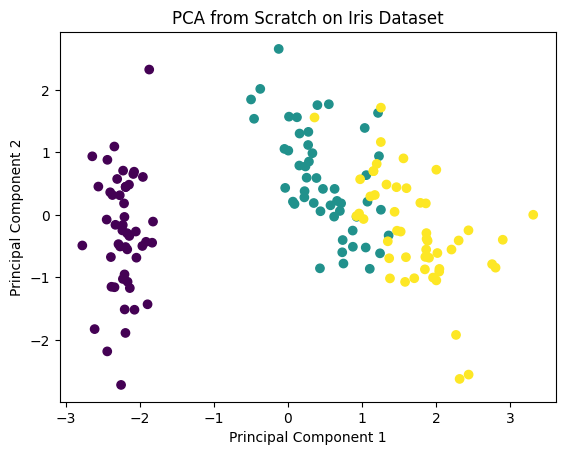

In [11]:
import matplotlib.pyplot as plt

# Encode species for color (only for visualization)
species_map = {"setosa": 0, "versicolor": 1, "virginica": 2}
y = df["species"].map(species_map).values

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA from Scratch on Iris Dataset")
plt.show()
